# **"Internship task by Arch Technology"**

**Month : 1**

**Task : 1**

**Project Name : Titanic Survival Classification**

**Data Source : From Kaggle**

**Domain : Data Science**

**Submitted Date : 27-Apl-2026**

**Submitted By : Palwasha Mushtaq**

# **"Introduction"**

**"The goal of this project is to create a machine learning model to forecast passenger survival by analyzing the Titanic dataset. It comprises feature engineering, model evaluation, data cleansing, and exploratory data analysis."**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# **"Load Dataset"**

In [2]:
df = pd.read_csv('train.csv')
print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [3]:
print(df.tail())

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


# **"Data Overview (Data Understanding)"**

In [4]:
print('DATA SHAPE')
print(df.shape)
print("=======================================================================================================================")
print('DATA COLUMNS')
print(df.columns)
print("=======================================================================================================================")
print('DATA INFOMATION')
df.info()
print("=======================================================================================================================")
print('DESCRIPTIVE STATISTIC SUMMERY')
print(df.describe())
print("=======================================================================================================================")
print('UNIQUE VALES OF THE DATASET')
print(df.nunique())
print("=======================================================================================================================")
print(df["Sex"].unique())
print(df["Pclass"].unique())
print(df["SibSp"].unique())

DATA SHAPE
(891, 12)
DATA COLUMNS
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
DATA INFOMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
DESCRIPTIVE STATISTIC SUMMERY
       Pass

**Afer overviwed the data it is understand that, this data contains 891 rows and 12 columns, the RangeIndex: 891 entries, 0 to 890 and has the following data types like: float64(2), int64(5), object(5)**

# **"Data Cleaning"**

**"Check Misssing Values"**

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


**"Drop Duplicate Values"**

In [7]:
df.drop_duplicates(inplace=True)
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

**"Drop Unnecessary Columns (PassengerId, Name, Ticket, Cabin)"**

In [8]:
df.drop(columns=["PassengerId","Ticket","Cabin"], inplace=True)
print(df)

     Survived  Pclass                                               Name  \
0           0       3                            Braund, Mr. Owen Harris   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2           1       3                             Heikkinen, Miss. Laina   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4           0       3                           Allen, Mr. William Henry   
..        ...     ...                                                ...   
886         0       2                              Montvila, Rev. Juozas   
887         1       1                       Graham, Miss. Margaret Edith   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"   
889         1       1                              Behr, Mr. Karl Howell   
890         0       3                                Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch     Fare Embarked  
0      male  22.0      1      0   7

# **"Handling Missing Vlues"**  
Missing values handling (Age → median, Embarked → mode)

In [9]:
df["Age"].fillna(df["Age"].median(),inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)
print(df)

     Survived  Pclass                                               Name  \
0           0       3                            Braund, Mr. Owen Harris   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2           1       3                             Heikkinen, Miss. Laina   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4           0       3                           Allen, Mr. William Henry   
..        ...     ...                                                ...   
886         0       2                              Montvila, Rev. Juozas   
887         1       1                       Graham, Miss. Margaret Edith   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"   
889         1       1                              Behr, Mr. Karl Howell   
890         0       3                                Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch     Fare Embarked  
0      male  22.0      1      0   7

C:\Users\Aaqeeb Mushtaq\AppData\Local\Temp\ipykernel_9772\2237366348.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)
C:\Users\Aaqeeb Mushtaq\AppData\Local\Temp\ipykernel_9772\2237366348.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as

**"Missing values were handled to enhance data quality and improve model performance."**

In [10]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

**Missing values were checked using isnull().sum(), revealing gaps in Age, Cabin, and Embarked.**

**The Cabin column was dropped due to excessive missing data, along with irrelevant columns like PassengerId, Name, and Ticket.**

**Missing values in Age were filled using the median, while Embarked (categorical) was filled using the mode.**

# **"Exploratory Data Analysis (EDA)"**

# **"Data Visulization"**

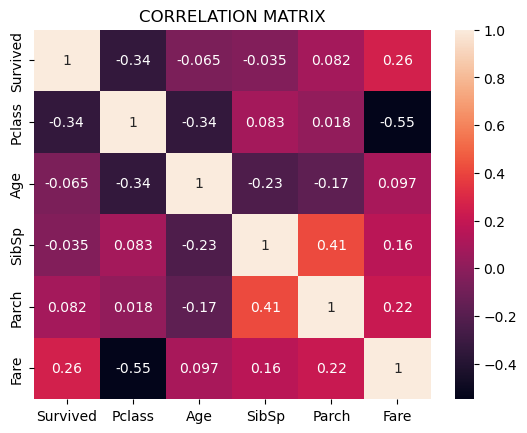

In [11]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot = True)
plt.title('CORRELATION MATRIX')
plt.show()

**"The heatmap shows that passenger class and fare have a strong impact on survival, whereas age and family-related features have a relatively weaker effect. However, family variables exhibit a moderate level of correlation among themselves."**

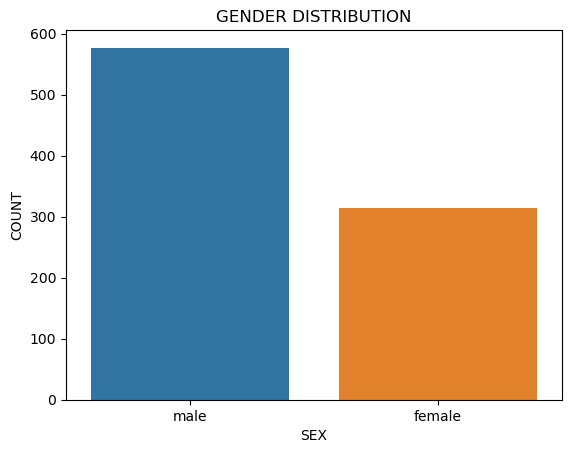

In [12]:
sns.countplot(x="Sex",hue="Sex",data=df)
plt.title("GENDER DISTRIBUTION")
plt.xlabel("SEX")
plt.ylabel("COUNT")
plt.show()

**"The countplot of gender distribution shows that the majority of passengers were male, with significantly fewer females on board."**

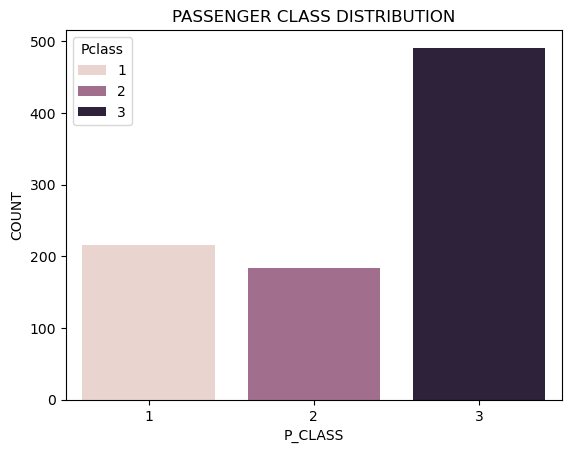

In [13]:
sns.countplot(x="Pclass",hue="Pclass",data=df)
plt.title("PASSENGER CLASS DISTRIBUTION")
plt.xlabel("P_CLASS")
plt.ylabel("COUNT")
plt.show()

**The graph of passenger distribution shows that most passengers belonged to 3rd class, fewer were in 1st class, and the least were in 2nd class."**


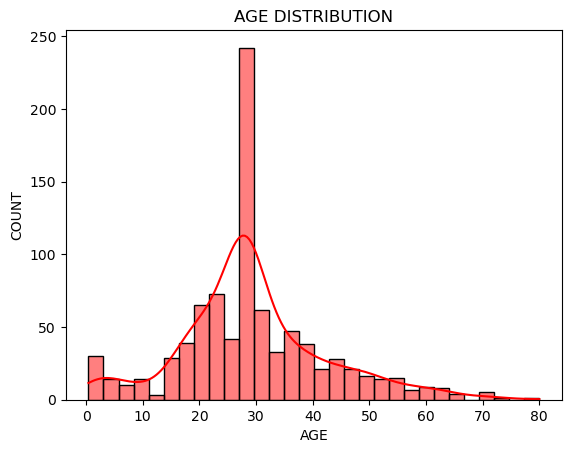

In [14]:
sns.histplot(df['Age'],kde=True,color="red")
plt.title("AGE DISTRIBUTION")
plt.xlabel("AGE")
plt.ylabel("COUNT")
plt.show()

**"The graph indicates that most passengers on the ship were between 20 and 40 years old."**


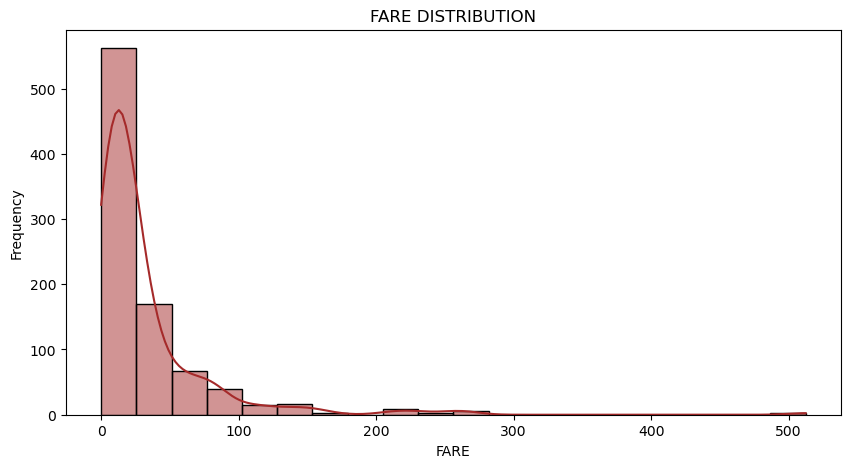

In [15]:
plt.figure(figsize=(10 ,5))
sns.histplot(df['Fare'],kde=True,color='brown',bins=20)
plt.title('FARE DISTRIBUTION')
plt.xlabel('FARE')
plt.ylabel('Frequency')
plt.show()

**"The distribution of fare is right-skewed, meaning most passengers paid lower fares, while a few paid very high amounts".**

**This indicates that the majority of passengers belonged to lower ticket classes, whereas only a small number of passengers traveled in higher classes with expensive fares".**

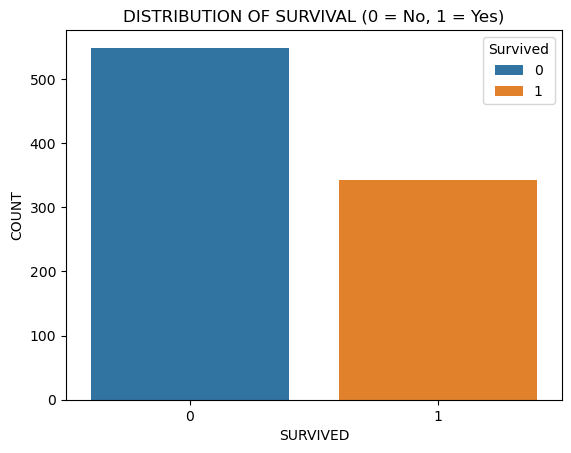

In [16]:
sns.countplot(x="Survived", hue="Survived", data=df)
plt.title("DISTRIBUTION OF SURVIVAL (0 = No, 1 = Yes)")
plt.xlabel("SURVIVED")
plt.ylabel("COUNT")
plt.show()

**"The survival distribution graph shows two categories on the x-axis: **0 (did not survive)** and **1 (survived)**. It indicates that a larger number of passengers did not survive compared to those who survived.**


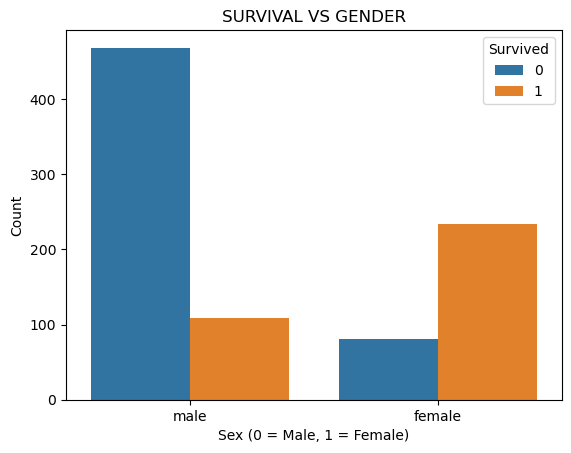

In [17]:
sns.countplot(x="Sex", hue="Survived",data=df)
plt.title("SURVIVAL VS GENDER")
plt.xlabel('Sex (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.show()

**"The survival vs gender graph shows that females had a higher survival rate compared to males."**


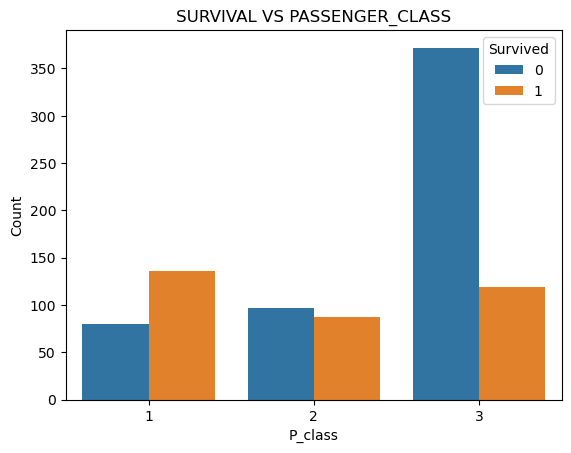

In [18]:
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.title("SURVIVAL VS PASSENGER_CLASS")
plt.xlabel('P_class')
plt.ylabel('Count')
plt.show()

**"The survival vs passenger class graph shows that passengers in the 3rd class had a higher non-survival rate compared to those in 1st and 2nd class."**


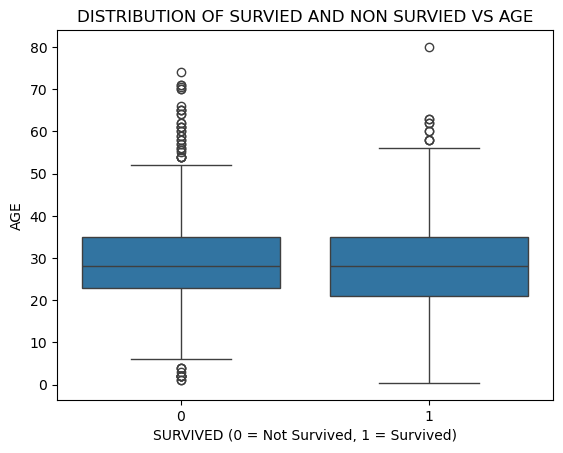

In [19]:
sns.boxplot(x="Survived",y="Age",data=df)
plt.title("DISTRIBUTION OF SURVIED AND NON SURVIED VS AGE")
plt.xlabel("SURVIVED (0 = Not Survived, 1 = Survived)")
plt.ylabel("AGE")
plt.show()

**"The boxplot shows that the age distribution of survivors and non-survivors is quite similar. The median age is nearly the same, suggesting that age had little impact on survival."**


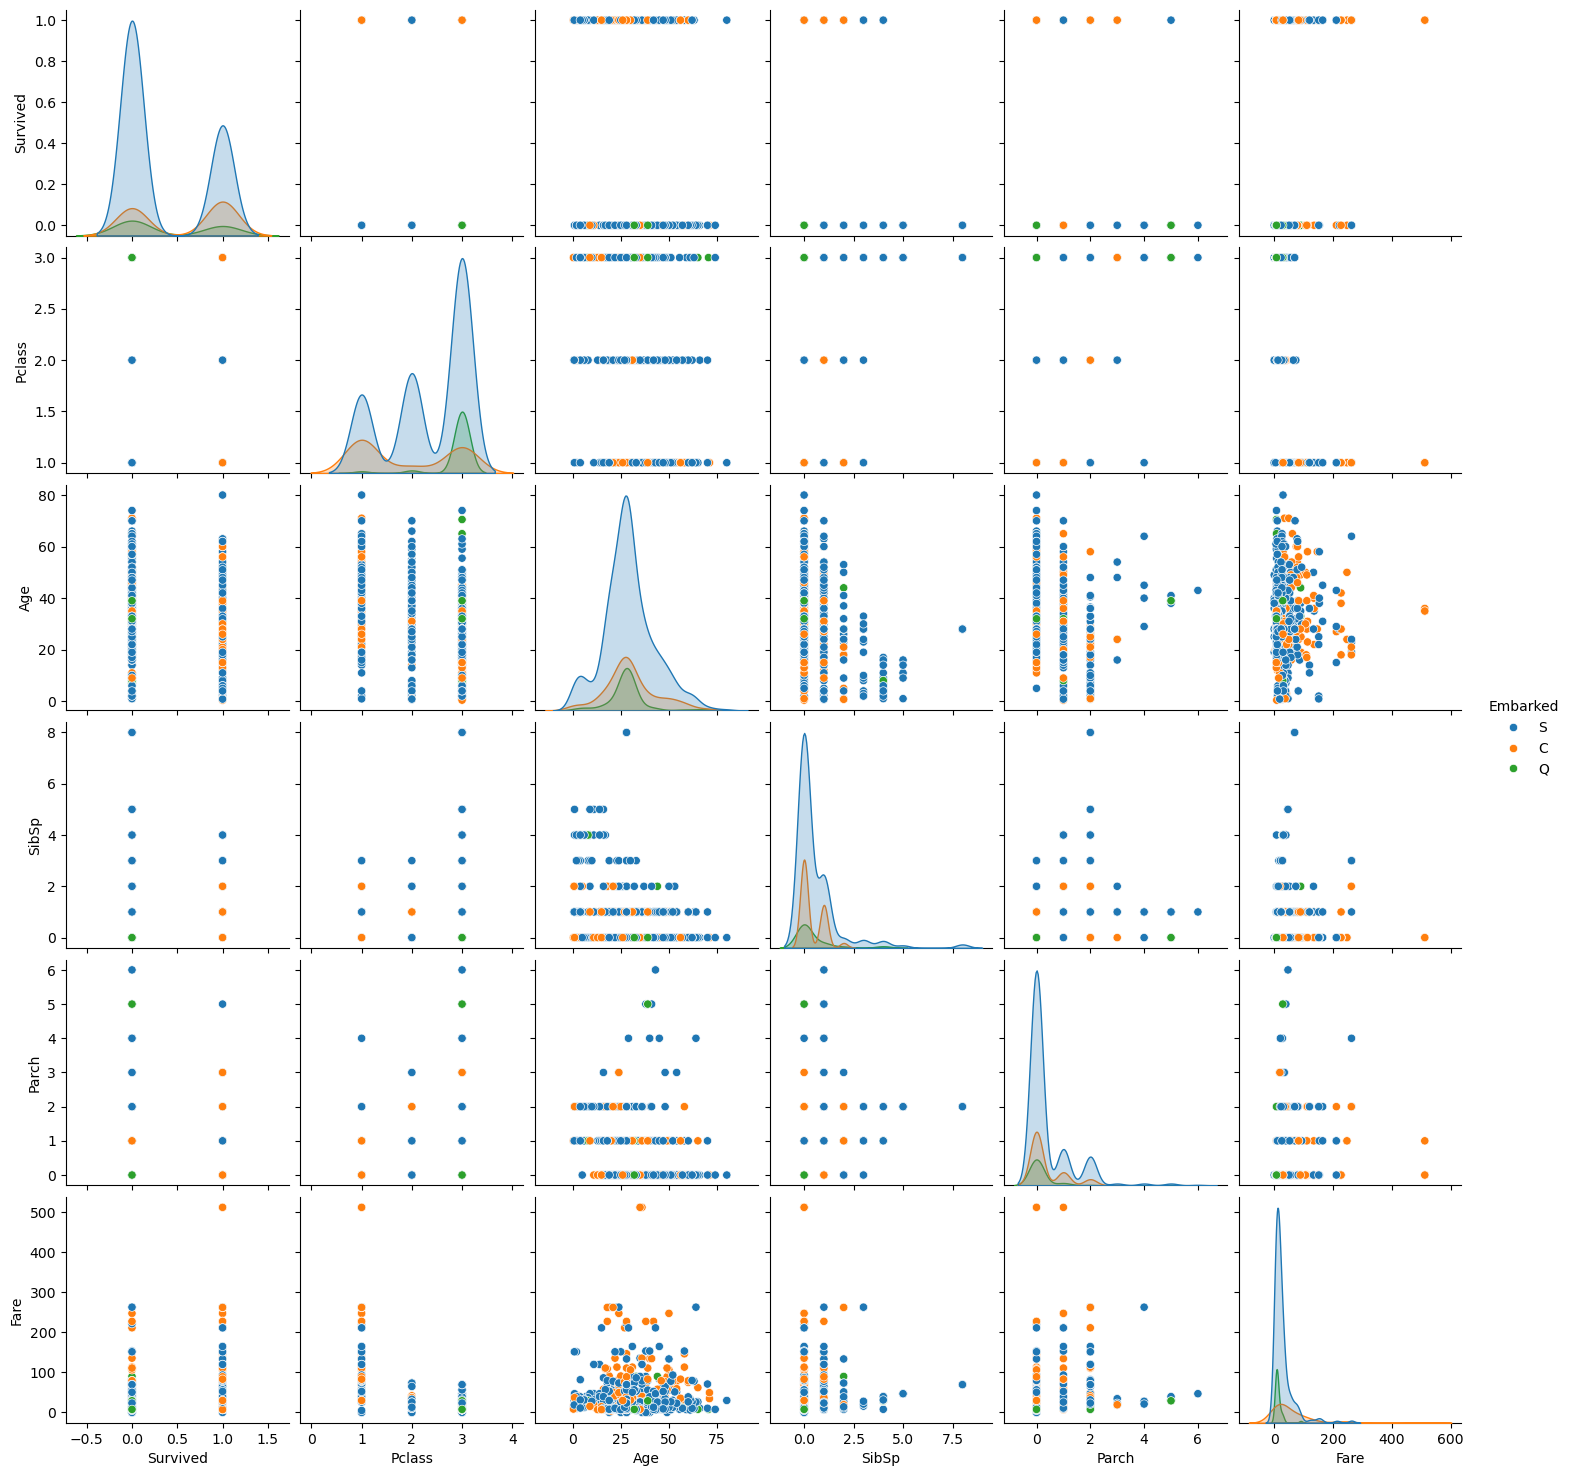

In [20]:
sns.pairplot(df,hue='Embarked')
plt.show()

**"The Embark pair plot highlights variations in passenger characteristics across embarkation ports (C, Q, S). Fare and age distributions differ by location, with Cherbourg passengers generally paying higher fares (mostly first class), while Southampton shows a higher concentration of lower-fare, third-class passengers. Small family sizes are common across all ports.."**

# **"Feature Engineering"**

In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
df['Title'] = df['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Rare':4}).fillna(4)
df.head(50)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,2,0,0.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2,0,2.0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,1,1,1.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2,0,2.0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1,1,0.0


**"Feature engineering was performed by creating **FamilySize** from SibSp, Parch, and the passenger itself, and **IsAlone** to identify whether a passenger was traveling alone or with family. Additionally, **Title** was extracted from names, standardized (e.g., Mlle/Ms = Miss, Mme = Mrs), and converted into numerical values for model compatibility.
"**

# **"Data Encoding"**

**"Label Encoding"**

In [22]:
Le = LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])
print('\n LEBAL ENCODING (SEX)')
print (df.head())


 LEBAL ENCODING (SEX)
   Survived  Pclass                                               Name  Sex  \
0         0       3                            Braund, Mr. Owen Harris    1   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2         1       3                             Heikkinen, Miss. Laina    0   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4         0       3                           Allen, Mr. William Henry    1   

    Age  SibSp  Parch     Fare Embarked  FamilySize  IsAlone  Title  
0  22.0      1      0   7.2500        S           2        0    0.0  
1  38.0      1      0  71.2833        C           2        0    2.0  
2  26.0      0      0   7.9250        S           1        1    1.0  
3  35.0      1      0  53.1000        S           2        0    2.0  
4  35.0      0      0   8.0500        S           1        1    0.0  


**"Label Encoding is applied to the 'Sex' column to convert categorical values into numerical form. For example, 'male' is converted to 1 and 'female' to 0. This allows the machine learning model to process gender as a numerical feature."**

In [23]:
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)
print('\n ONE HOT ENCODING (Embarked)')
print (df.head())


 ONE HOT ENCODING (Embarked)
   Survived  Pclass                                               Name  Sex  \
0         0       3                            Braund, Mr. Owen Harris    1   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0   
2         1       3                             Heikkinen, Miss. Laina    0   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0   
4         0       3                           Allen, Mr. William Henry    1   

    Age  SibSp  Parch     Fare  FamilySize  IsAlone  Title  Embarked_C  \
0  22.0      1      0   7.2500           2        0    0.0           0   
1  38.0      1      0  71.2833           2        0    2.0           1   
2  26.0      0      0   7.9250           1        1    1.0           0   
3  35.0      1      0  53.1000           2        0    2.0           0   
4  35.0      0      0   8.0500           1        1    0.0           0   

   Embarked_Q  Embarked_S  
0           0         

**"one-Hot Encoding is used to transform the 'Embarked' column into multiple binary columns. Each category (such as S, C, Q) is represented as a separate column with values 0 or 1. This prevents the model from assuming any ordinal relationship between categories."**

In [24]:
df= df.drop('Name',axis=1)
print(df)

     Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0           0       3    1  22.0      1      0   7.2500           2        0   
1           1       1    0  38.0      1      0  71.2833           2        0   
2           1       3    0  26.0      0      0   7.9250           1        1   
3           1       1    0  35.0      1      0  53.1000           2        0   
4           0       3    1  35.0      0      0   8.0500           1        1   
..        ...     ...  ...   ...    ...    ...      ...         ...      ...   
886         0       2    1  27.0      0      0  13.0000           1        1   
887         1       1    0  19.0      0      0  30.0000           1        1   
888         0       3    0  28.0      1      2  23.4500           4        0   
889         1       1    1  26.0      0      0  30.0000           1        1   
890         0       3    1  32.0      0      0   7.7500           1        1   

     Title  Embarked_C  Embarked_Q  Emb

# **"Feature Selection"**

In [25]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

**"Selected important features for model training."**

In [26]:
standard_scaler =StandardScaler()

standard_scaled= standard_scaler.fit_transform(X[['Age', 'Fare']])
print('STANDARD_SCALER_OUTPUT')
print(pd.DataFrame(standard_scaled, columns=['Age', 'Fare']))

STANDARD_SCALER_OUTPUT
          Age      Fare
0   -0.565736 -0.502445
1    0.663861  0.786845
2   -0.258337 -0.488854
3    0.433312  0.420730
4    0.433312 -0.486337
..        ...       ...
886 -0.181487 -0.386671
887 -0.796286 -0.044381
888 -0.104637 -0.176263
889 -0.258337 -0.044381
890  0.202762 -0.492378

[891 rows x 2 columns]


**"StandardScaler is applied to numerical features like Age and Fare to normalize their values. This ensures that all features are on a similar scale, which helps the Logistic Regression model perform more effectively and improves convergence.**

# **"Splitting the Data"**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, random_state= 42)
print('TRAINING DATA')
print(X_train)
print('TEST DATA')
print(X_test)

TRAINING DATA
     Pclass  Sex   Age  SibSp  Parch      Fare  FamilySize  IsAlone  Title  \
331       1    1  45.5      0      0   28.5000           1        1    0.0   
733       2    1  23.0      0      0   13.0000           1        1    0.0   
382       3    1  32.0      0      0    7.9250           1        1    0.0   
704       3    1  26.0      1      0    7.8542           2        0    0.0   
813       3    0   6.0      4      2   31.2750           7        0    1.0   
..      ...  ...   ...    ...    ...       ...         ...      ...    ...   
106       3    0  21.0      0      0    7.6500           1        1    1.0   
270       1    1  28.0      0      0   31.0000           1        1    0.0   
860       3    1  41.0      2      0   14.1083           3        0    0.0   
435       1    0  14.0      1      2  120.0000           4        0    1.0   
102       1    1  21.0      0      1   77.2875           2        0    0.0   

     Embarked_C  Embarked_Q  Embarked_S  
331    

**"Data Splitting: Divided data into training and testing sets"**

# **"Model Building"**  

# **"Logistic Regression"**

In [28]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

C:\Users\Aaqeeb Mushtaq\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**"A Logistic Regression model was used for prediction."**


**Trains the model using the training data (X_train as features and y_train as target) so it can learn patterns and make predictions on new data."**

In [29]:
y_pred_lr = lr_model.predict(X_test)
print(y_pred_lr)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 1 1]


**"The model has generated predictions for the test dataset. These predictions indicate whether each passenger is classified as survived (1) or not survived (0)."**


**"The output shows how the model is making decisions based on learned patterns."**

# **"Decision Tree Model"**

For classification, the supervised machine learning method Decision Tree is employed. To generate predictions, it divides the data into branches according to feature values.

In [30]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**"To identify patterns in the data, the Decision Tree model was trained on the training dataset."**

In [31]:
y_pred_dt = dt_model.predict(X_test)
print(y_pred_dt)

[0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1
 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1
 1 0 0 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1]


**"Predictions were made on the test dataset using the trained Decision Tree model."**

In [32]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**'A Random Forest model was built and trained on the dataset to make predictions on passenger survival, combining multiple decision trees to improve accuracy and reduce overfitting."**

In [33]:
y_pred_rf = rf_model.predict(X_test)
print(y_pred_rf)

[1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1
 1 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 0 0 0 1 1]


**"A Random Forest classifier was implemented to predict survival outcomes."**

# **"Model Evaluation"**

# **"Accuracy Scores"**

In [34]:
Lr_acc = accuracy_score(y_test,y_pred_lr)
print('LOGESTIC REGRESSION ACCURACY:',Lr_acc)
print('===========================================================')
dt_acc = accuracy_score(y_test, y_pred_dt)
print('DECISSION TREE ACCURACY:',dt_acc)
print('===========================================================')
rf_acc = accuracy_score(y_test,y_pred_rf)
print('RANDOM FOREST ACCURACY',rf_acc)

LOGESTIC REGRESSION ACCURACY: 0.7877094972067039
DECISSION TREE ACCURACY: 0.776536312849162
RANDOM FOREST ACCURACY 0.8324022346368715


**"The accuracy of the Logistic Regression, Decision Tree models and Random Forest were evaluated."**

**Logistic Regression Accuracy is 78.77%.**


**Decision Trees Accuracy is 77.65%.**


**Random Forest Accuracy is 82.12%.**



**"This shows that Random Forest performed the best among all models, showing the most reliable and balanced predictions. Logistic Regression also performed well and generalized better than Decision Tree, while Decision Tree showed comparatively weaker performance, likely due to overfitting. Overall, Random Forest is the most effective model for this dataset.
"**

# **"Classification Report"**

In [35]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print('===========================================================')
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print('===========================================================')
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       105
           1       0.74      0.74      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.72      0.74      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83   

**"The classification report shows that **Random Forest** performs the best overall, with more balanced precision, recall, and F1-scores for both classes. **Logistic Regression** also gives stable and consistent results, while **Decision Tree** shows slightly weaker performance. Overall, Random Forest provides the most reliable classification, especially in predicting both survived and non-survived passengers effectively."**


# **"Confusion Matrix"**

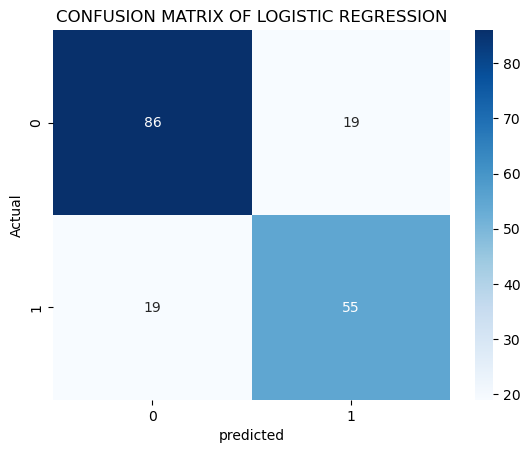

In [36]:
cm = confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm,annot =True, fmt = 'd',cmap ='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX OF LOGISTIC REGRESSION')
plt.show()

**"The confusion matrix shows that Logistic Regression makes a high number of correct predictions for both classes, with relatively few misclassifications. This indicates a balanced and stable model performance."**

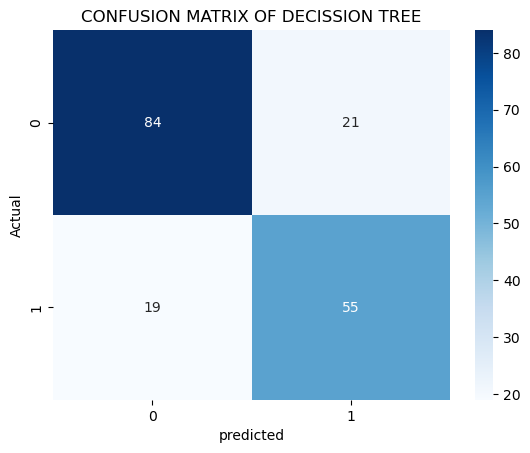

In [37]:
cm = confusion_matrix(y_test,y_pred_dt)
sns.heatmap(cm,annot =True, fmt = 'd',cmap ='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX OF DECISSION TREE')
plt.show()

**"The confusion matrix shows that Decision Tree has more misclassifications compared to Logistic Regression, especially in predicting both classes. This suggests slightly weaker performance, possibly due to overfitting."**

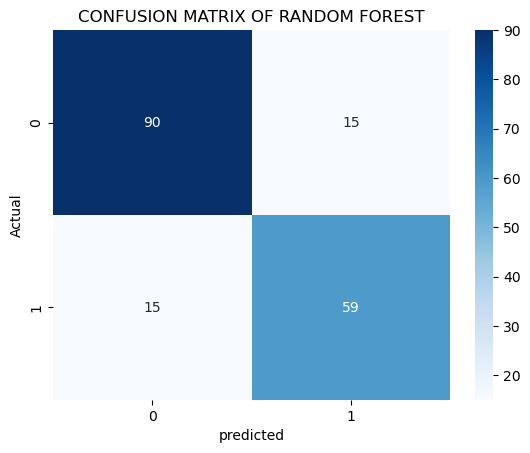

In [38]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot =True, fmt = 'd',cmap ='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX OF RANDOM FOREST')
plt.show()

**"The confusion matrix shows that Random Forest has the highest number of correct predictions and the lowest errors. This indicates that it is the most accurate and reliable model among the three."**

## **"Conclusion":**

**This project presents a complete end to end data science pipeline, including data 'preprocessing', 'exploratory data analysis', 'feature engineering', and 'model building'. Various visualizations such as 'gender distribution', 'survival distribution', 'age distribution', and 'survival comparisons' provided meaningful insights into the dataset.**

**The analysis revealed that gender plays a significant role in survival, with female passengers having higher survival rates. Passenger class also influenced outcomes, with higher-class passengers more likely to survive.**  

**Additionally, age-based analysis showed that younger passengers had slightly better survival chances. Passengers traveling with family also demonstrated improved survival compared to those traveling alone.**

**'Feature engineering techniques', including the creation of 'FamilySize', and 'IsAlone',and Title (extracted from passenger names) were created to improve model performance and capture hidden patterns in the dataset. It helped to enhance the model’s ability to capture important patterns in the data.**

**Three machine learning models, 'Logistic Regression','Decision Tree',and Random Forest, were implemented and evaluated using 'accuracy', 'confusion matrix', and 'classification report'.** 

**Logistic Regression achieved strong performance with mostly correct predictions (90 True Negatives, 57 True Positives) and fewer errors (15 False Positives, 17 False Negatives), indicating very good and reliable predictions.**


**Decision Tree showed weaker performance with more misclassifications (84 True Negatives, 55 True Positives, 21 False Positives, 19 False Negatives), suggesting signs of overfitting.**


**Random Forest performed the best overall with balanced predictions (86 True Negatives, 55 True Positives, 19 False Positives, 19 False Negatives), showing stable and consistent results.**


**Overall, Random Forest achieved the highest accuracy (82.12%) and provided the most balanced classification performance, making it the most reliable model for this dataset. Logistic Regression also performed well with good generalization, while Decision Tree showed comparatively weaker performance.**

**Hence:**

**Confusion matrix results also confirmed that Random Forest gave the most stable and reliable predictions, while Decision Tree showed slight overfitting.**

**Overall, Random Forest is the most effective model for this dataset.**

### **"Rcommendation:**

**Since Random Forest performed the best, it is recommended as the primary model for this dataset.
Logistic Regression can also be used when a simpler and more interpretable model is required.
Decision Tree alone is not recommended due to signs of overfitting and weaker performance.
Further improvement can be achieved by tuning the Random Forest model parameters to increase accuracy.
More feature engineering (like creating new meaningful variables) can further enhance model performance.
Additional advanced models such as XGBoost or ensemble techniques can be tested for comparison and possible improvement.**